In [15]:
import yfinance as yf
msft = yf.Ticker("MPC")
aapl = yf.Ticker("PSX")
df_msft=msft.history(period="40y")
df_apple=aapl.history(period="40y")

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
np.random.seed(9823)

df_msft.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3745.000000,3745.000000,3745.000000,3745.000000,3.745000e+03,3745.000000,3745.000000
mean,66.464862,67.435814,65.523163,66.486539,5.552836e+06,0.007694,0.000534
std,54.249148,54.999510,53.545641,54.294119,3.082130e+06,0.068538,0.032682
min,8.845671,9.175730,8.697144,8.931489,8.952000e+05,0.000000,0.000000
25%,30.074600,30.637849,29.587805,30.101130,3.414000e+06,0.000000,0.000000
50%,42.841786,43.376259,42.478064,42.954239,5.076200e+06,0.000000,0.000000
75%,91.711407,92.804396,90.155216,91.424240,6.923700e+06,0.000000,0.000000
max,256.000000,261.609985,251.889999,260.510010,3.915380e+07,1.000000,2.000000


In [17]:
data_apple = df_apple["Close"]
data_microsoft = df_msft["Close"]
data_apple = data_apple[-3500:]
data_microsoft = data_microsoft[-3500:]
print(len(data_microsoft))

3500


In [18]:
# AI generated
def estimate_all_params(S1, S2):
    S1, S2 = np.array(S1), np.array(S2)

    # Step 1: estimate beta, keep the intercept
    model     = LinearRegression(fit_intercept=True).fit(S2.reshape(-1,1), S1)
    beta      = -model.coef_[0]
    intercept =  model.intercept_

    # Step 2: construct series, removing the regression intercept from eps
    eps = S1 + beta * S2 - intercept   # now mean-zero; c1 is purely the AR drift
    e   = np.diff(S2)

    # Step 3: fit AR(1)
    def fit_ar1(series):
        res = AutoReg(series, lags=1).fit()
        c, phi = res.params
        sigma  = np.sqrt(res.sigma2)
        return phi, c, sigma

    phi1, c1, sigma1 = fit_ar1(eps)
    phi2, c2, sigma2 = fit_ar1(e)

    return dict(beta=beta, intercept=intercept,
                phi1=phi1, c1=c1, sigma1=sigma1,
                phi2=phi2, c2=c2, sigma2=sigma2)

Window 0: c1=0.010565364282875328 c2=0.04117276858772532 phi1=0.975, phi2=-0.004, sigma1=0.4721, sigma2=0.4844, beta=-1.416
Window 1: c1=0.005316084269768645 c2=0.02159256019224493 phi1=0.975, phi2=0.067, sigma1=0.6812, sigma2=0.6113, beta=-0.346
Window 2: c1=0.0058035100616835745 c2=0.00665269849439982 phi1=0.964, phi2=-0.025, sigma1=0.7033, sigma2=0.7662, beta=-0.291
Window 3: c1=-0.00810038450017455 c2=0.052268115815597135 phi1=0.979, phi2=0.029, sigma1=0.7187, sigma2=0.8773, beta=-1.147
Window 4: c1=0.04189855131387825 c2=-0.05640096869541917 phi1=0.988, phi2=0.009, sigma1=0.9810, sigma2=1.2102, beta=-1.007
Window 5: c1=-0.04787659386235662 c2=0.07719381967293755 phi1=0.979, phi2=-0.084, sigma1=1.0284, sigma2=1.0434, beta=-0.677
Window 6: c1=0.016976163140134743 c2=0.1818299525171487 phi1=0.955, phi2=-0.046, sigma1=1.1888, sigma2=2.1631, beta=-0.461
Window 7: c1=0.03615650235691788 c2=0.015131843683506466 phi1=0.971, phi2=0.016, sigma1=1.2902, sigma2=2.9103, beta=-0.728


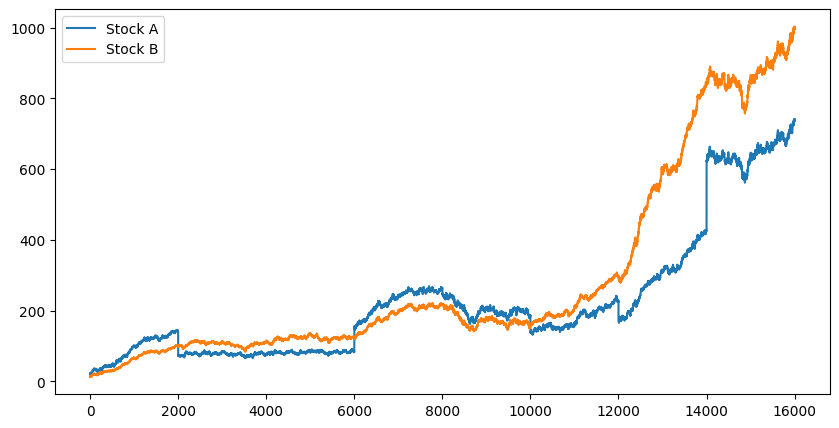

In [19]:
s1 = data_apple.values
s2 = data_microsoft.values

window_size = 400
points_per_window = 2000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
for i in range(len(s1)//window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    for j in range(points_per_window):
        epst = params["c1"]+params["sigma1"]*np.random.normal()+params["phi1"]*epst
        et = params["c2"]+params["sigma2"]*np.random.normal()+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

for i in range(len(s1) // window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    print(f"Window {i}: c1={params["c1"]} c2={params["c2"]} phi1={params['phi1']:.3f}, phi2={params['phi2']:.3f}, "
          f"sigma1={params['sigma1']:.4f}, sigma2={params['sigma2']:.4f}, "
          f"beta={params['beta']:.3f}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen, label = "Stock A")
ax.plot(s2_gen, label = "Stock B")
# ax.set_yscale('log')
ax.legend()
plt.show()

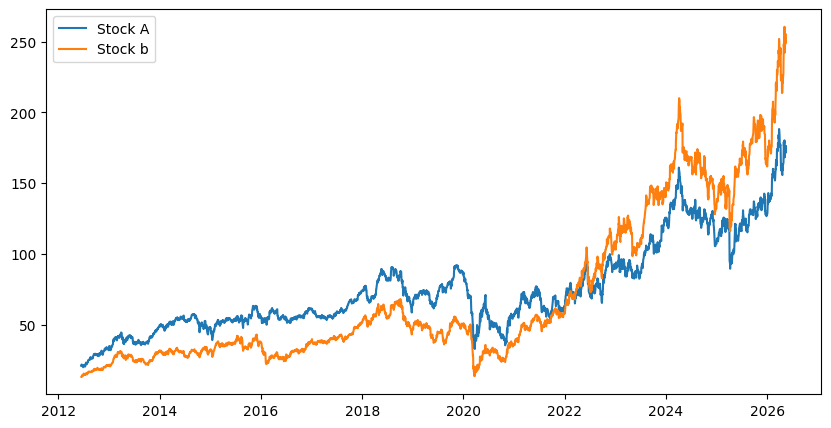

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_apple, label="Stock A")
ax.plot(data_microsoft, label="Stock b")
# ax.set_yscale('log')
ax.legend()

In [21]:
"""
s1 = np.log(data_apple.values)
s2 = np.log(data_microsoft.values)

window_size = 300
points_per_window = 100
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
betas = []
for i in range(len(s1)-window_size):
    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])
    betas.append(params["beta"])
    for j in range(points_per_window):
        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi1"]*epst
        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])
"""

'\ns1 = np.log(data_apple.values)\ns2 = np.log(data_microsoft.values)\n\nwindow_size = 300\npoints_per_window = 100\ns1_gen = [s1[0]]\ns2_gen = [s2[0]]\net=s2[1]-s2[0]\nepst=0\nbetas = []\nfor i in range(len(s1)-window_size):\n    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])\n    betas.append(params["beta"])\n    for j in range(points_per_window):\n        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi1"]*epst\n        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi2"]*et\n        s2_gen.append(et+s2_gen[-1])\n        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])\n'

In [22]:
"""
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(betas, label = "beta")
ax.legend()
plt.show()
s1_gen = np.array(s1_gen)
s2_gen = np.array(s2_gen)
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(np.exp(s1_gen[1:]), label="Stock A")
ax.plot(np.exp(s2_gen[1:]), label="Stock b")
# ax.set_yscale('log')
ax.legend()
"""

'\nfig, ax = plt.subplots(figsize=(20, 5))\nax.plot(betas, label = "beta")\nax.legend()\nplt.show()\ns1_gen = np.array(s1_gen)\ns2_gen = np.array(s2_gen)\nfig, ax = plt.subplots(figsize=(20, 5))\nax.plot(np.exp(s1_gen[1:]), label="Stock A")\nax.plot(np.exp(s2_gen[1:]), label="Stock b")\n# ax.set_yscale(\'log\')\nax.legend()\n'

# Static Threshold Baseline

In [23]:
def static_threshold_baseline(s1, s2, lookback=60, entry_z=2.0, exit_z=0.5):
    s1, s2 = np.array(s1, dtype=float), np.array(s2, dtype=float)
    log_s1, log_s2 = np.log(s1), np.log(s2)

    # Rolling beta and spread: at each t, beta estimated from [t-lookback, t) only
    spread = np.full(len(s1), np.nan)
    betas  = np.full(len(s1), np.nan)
    for t in range(lookback, len(s1)):
        w1, w2 = log_s1[t - lookback:t], log_s2[t - lookback:t]
        beta_t = LinearRegression(fit_intercept=False).fit(w2.reshape(-1, 1), w1).coef_[0]
        betas[t]  = beta_t
        spread[t] = log_s1[t] - beta_t * log_s2[t]

    # Rolling z-score over the same lookback window
    z = np.full(len(spread), np.nan)
    for t in range(lookback * 2, len(spread)):
        window = spread[t - lookback:t]
        z[t] = (spread[t] - window.mean()) / (window.std() + 1e-10)

    # Trading logic
    position = np.zeros(len(spread))
    pos = 0
    for t in range(lookback * 2, len(spread)):
        if pos == 0:
            if z[t] < -entry_z:
                pos = 1
            elif z[t] > entry_z:
                pos = -1
        elif abs(z[t]) < exit_z:
            pos = 0
        position[t] = pos

    # Log-return P&L
    spread_ret = np.diff(spread)
    pnl = np.zeros(len(spread))
    pnl[1:] = position[:-1] * spread_ret

    # Dollar P&L: beta_log is an elasticity, so dollar hedge = beta_log * (s1/s2)
    beta_dollar = betas * (s1 / s2)
    dollar_pnl = np.zeros(len(s1))
    dollar_pnl[1:] = position[:-1] * (np.diff(s1) - beta_dollar[:-1] * np.diff(s2))

    cum_ret        = np.nancumsum(pnl)
    cum_dollar_pnl = np.nancumsum(dollar_pnl)
    sharpe  = pnl[lookback*2:].mean() / (pnl[lookback*2:].std() + 1e-10) * np.sqrt(252)
    max_dd  = np.max(np.maximum.accumulate(cum_ret) - cum_ret)

    return dict(z=z, position=position, pnl=pnl, cum_ret=cum_ret,
                dollar_pnl=dollar_pnl, cum_dollar_pnl=cum_dollar_pnl,
                sharpe=sharpe, total_ret=cum_ret[-1], max_dd=max_dd)

OU:  k=0.150, theta=-0.1672, eta=0.2341
B:   sigma=0.3879, rho=-0.5135
T_max (no singularity) = 9.395 yr, using T = 9.395 yr
ODE solved: 1316 points (expected 2368)


NameError: name 'results' is not defined

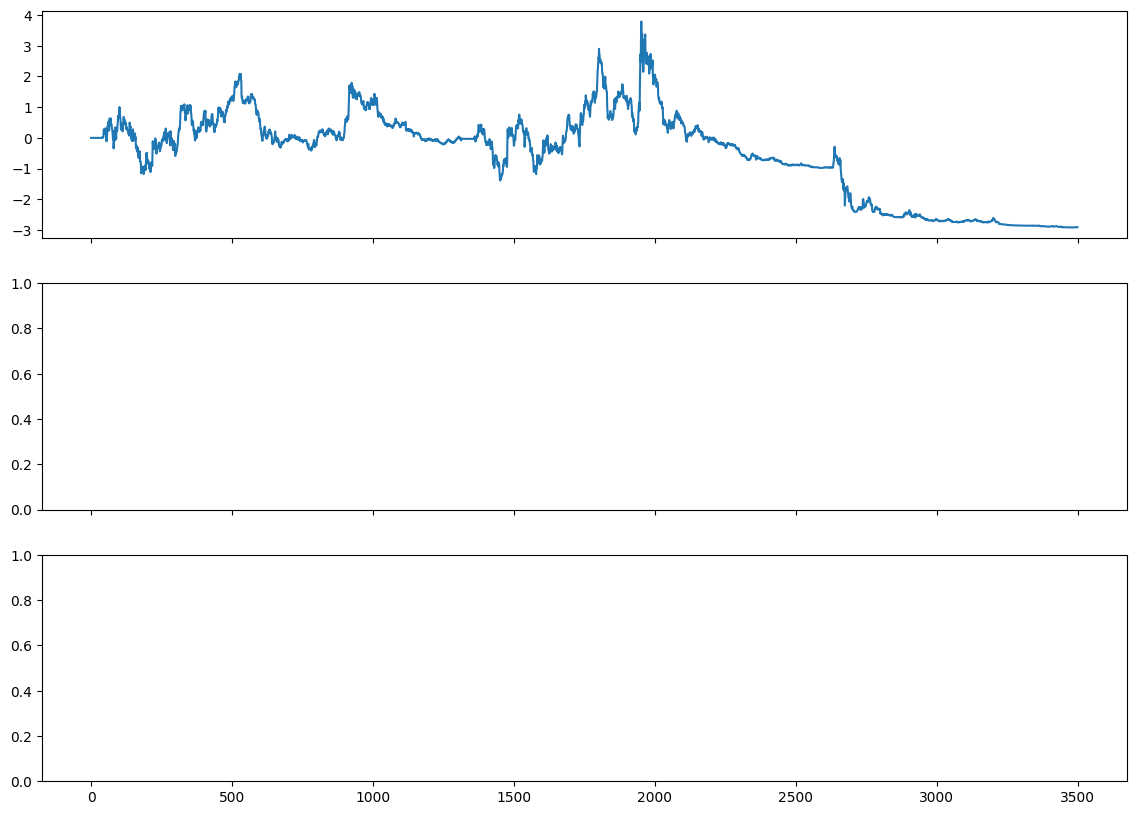

In [24]:
from scipy.integrate import solve_ivp

def fit_ou_params(X, dt=1/252):
    res = AutoReg(np.array(X), lags=1).fit()
    phi = np.clip(res.params[1], 1e-6, 1 - 1e-6)
    k = -np.log(phi) / dt
    theta = res.params[0] / (1 - phi)
    sigma_eps = np.sqrt(res.sigma2)
    eta = sigma_eps * np.sqrt(2 * k / (1 - np.exp(-2 * k * dt)))
    return k, theta, eta


def yu_optimal_strategy(s1, s2, r=0.05, lam=-0.4, T_years=None, dt=1/252):
    """
    Yu et al. (2021) optimal pairs trading strategy.
    T is automatically capped at π/(2k)*0.9 to avoid the Riccati singularity.
    """
    s1, s2 = np.array(s1, dtype=float), np.array(s2, dtype=float)
    n = len(s1)

    X = np.log(s1) - np.log(s2)

    # --- 1. Parameter estimation ---
    k, theta_ou, eta = fit_ou_params(X, dt=dt)
    ret_s2 = np.diff(np.log(s2))
    sigma_b = ret_s2.std() / np.sqrt(dt)
    ou_innov = np.diff(X) - k * (theta_ou - X[:-1]) * dt
    rho = np.corrcoef(ret_s2, ou_innov)[0, 1]

    # Cap T to avoid Riccati singularity at T - π/(2k)
    T_max = np.pi / (2 * k) * 0.9
    T = T_max if T_years is None else min(T_years, T_max)
    print(f"OU:  k={k:.3f}, theta={theta_ou:.4f}, eta={eta:.4f}")
    print(f"B:   sigma={sigma_b:.4f}, rho={rho:.4f}")
    print(f"T_max (no singularity) = {T_max:.3f} yr, using T = {T:.3f} yr")

    # --- 2. Solve ODEs for m1, n1, l1 backward from T (Eq. 27) ---
    n_ode = min(n, int(T / dt) + 1)
    t_grid = np.linspace(T, 0, n_ode)

    def sys1(t, y):
        m1, n1, l1 = y
        et, k_, th, rh, sg, r_ = eta, k, theta_ou, rho, sigma_b, r
        dm1 = -(2*k_*m1 - 2*et**2*m1**2 - k_**2/et**2)
        dn1 = -(k_*n1 - 2*k_*th*m1 - 2*et**2*m1 - 4*rh*sg*et*m1
                - 2*et**2*m1*n1 + 2*k_**2*th/et**2 + k_ + 2*k_*rh*sg/et)
        dl1 = -(-k_*th*n1 - et**2*n1 - 2*rh*sg*et*n1 + et**2*m1 + 2*r_
                - k_**2*th**2/et**2 - k_*th - 2*k_*th*rh*sg/et
                - et**2/4 - rh*sg*et - rh**2*sg**2)
        return [dm1, dn1, dl1]

    sol1 = solve_ivp(sys1, (T, 0.0), [0.0, 0.0, 0.0],
                     t_eval=t_grid, method='RK45', rtol=1e-6, atol=1e-8)
    m1_t = sol1.y[0][::-1]
    n1_t = sol1.y[1][::-1]
    l1_t = sol1.y[2][::-1]
    print(f"ODE solved: {len(sol1.t)} points (expected {n_ode})")

    # --- 3. Solve ODEs for m2, n2, l2 backward from T (Eq. 29, b>0) ---
    def sys2(t, y):
        m2, n2, l2 = y
        et, k_, th, rh, sg, r_ = eta, k, theta_ou, rho, sigma_b, r
        idx = np.clip(int(round((T - t) / dt)), 0, len(m1_t) - 1)
        m1, n1 = m1_t[idx], n1_t[idx]
        dm2 = -(2*et**2*m2**2 + 2*k_*m1 - 4*et**2*m1*m2 - k_**2/et**2)
        dn2 = -(2*et**2*m2*n2 - et**2*m2 - 2*rh*sg*et*m2 + k_*n1
                - 2*k_*th*m2 - 3*et**2*m1*n2 - 2*rh*sg*et*m1
                + 2*k_**2*th/et**2 + k_ + 2*k_*rh*sg/et)
        dl2 = -(et**2*n2**2/2 + et**2*m2 - (et**2/2 + rh*sg*et)*n2
                - k_*th*(n1 + n2) + r_
                - k_**2*th**2/et**2 - k_*th - 2*k_*th*rh*sg/et
                - et**2/4 - rh*sg*et - rh**2*sg**2)
        return [dm2, dn2, dl2]

    sol2 = solve_ivp(sys2, (T, 0.0), [0.0, 0.0, 0.0],
                     t_eval=t_grid, method='RK45', rtol=1e-6, atol=1e-8)
    m2_t = sol2.y[0][::-1]
    n2_t = sol2.y[1][::-1]
    l2_base_t = sol2.y[2][::-1]

    # --- 4. Apply strategy in rolling windows of length T ---
    positions = np.zeros(n)
    V = np.ones(n)
    window = len(m1_t)

    for i in range(1, n):
        x = X[i - 1]
        v = V[i - 1]
        # Index within the current T-window (resets every window steps)
        tau_idx = min(i % window, window - 1)
        m1, n1, l1 = m1_t[tau_idx], n1_t[tau_idx], l1_t[tau_idx]
        m2, n2 = m2_t[tau_idx], n2_t[tau_idx]
        l2 = l2_base_t[tau_idx] + np.log(-lam)

        delta = (k * (theta_ou - x) + eta**2 / 2 + rho * sigma_b * eta) / eta
        P = m1*x**2 + n1*x + l1
        Q = m2*x**2 + n2*x + l2
        exp_P = np.exp(np.clip(P, -50, 50))
        exp_Q = np.exp(np.clip(Q, -50, 50))

        A = 4*m1*eta*x + 2*n1*eta + 2*delta
        B = 2*m2*eta*x + n2*eta + delta
        h_star = -(A * exp_P * v + B * exp_Q) / (2 * eta * v * exp_P + 1e-10)
        positions[i] = np.clip(h_star, -10, 10)
        V[i] = V[i-1] * (1 + positions[i-1] * (X[i] - X[i-1]) + r * dt)

    pnl = np.zeros(n)
    pnl[1:] = positions[:-1] * np.diff(X)
    cum_pnl = np.nancumsum(pnl)
    sharpe = pnl[252:].mean() / (pnl[252:].std() + 1e-10) * np.sqrt(252)

    return dict(positions=positions, V=V, pnl=pnl, cum_pnl=cum_pnl,
                k=k, theta=theta_ou, eta=eta, rho=rho, sharpe=sharpe, T=T)


results_yu = yu_optimal_strategy(data_apple.values, data_microsoft.values)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(results_yu['cum_pnl'], label='Yu et al. optimal')
axes[0].plot(results['cum_ret'], label='Z-score baseline', alpha=0.7)
axes[0].set_title('Cumulative P&L comparison')
axes[0].legend()
axes[1].plot(results_yu['positions'], alpha=0.5, linewidth=0.5)
axes[1].set_title('Optimal position h*(t)')
axes[2].plot(results['position'], alpha=0.5, linewidth=0.5)
axes[2].set_title('Z-score position')
plt.tight_layout()
plt.show()

print(f"Yu optimal Sharpe:       {results_yu['sharpe']:.3f}")
print(f"Z-score baseline Sharpe: {results['sharpe']:.3f}")

xi=-0.796, singularity at t=1.153 years (solver stops here)


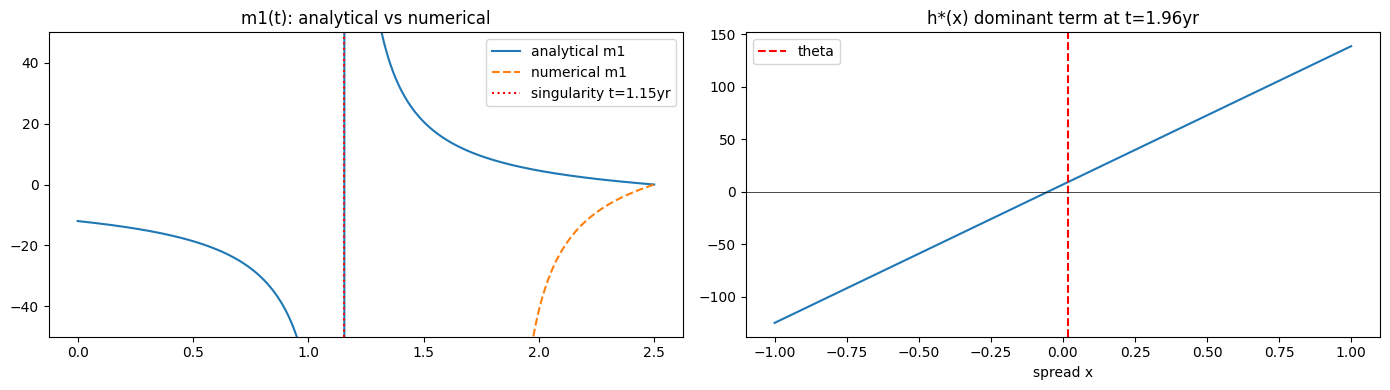

In [ ]:
k_p, theta_p, eta_p = 1.1664, 0.0173, 0.2341
rho_p, sigma_p, r_p, T_p = -0.8010, 0.4921, 0.05, 2.5

def m1_analytical(t, k, eta, T):
    xi = (np.cos(k*T/2) - np.sin(k*T/2)) / (np.cos(k*T/2) + np.sin(k*T/2))
    den = 4 * eta**2 * (xi*np.cos(k*t/2) + np.sin(k*t/2))
    if abs(den) < 1e-10:
        return np.nan
    num = -k * (xi*np.cos(k*t/2) + np.sin(k*t/2) + xi*np.sin(k*t/2) - np.cos(k*t/2))
    return num / den

t_vals = np.linspace(0, T_p, 500)
m1_exact = np.array([m1_analytical(t, k_p, eta_p, T_p) for t in t_vals])

# Singularity: xi*cos(k*t/2) + sin(k*t/2) = 0 => tan(k*t/2) = -xi
xi = (np.cos(k_p*T_p/2) - np.sin(k_p*T_p/2)) / (np.cos(k_p*T_p/2) + np.sin(k_p*T_p/2))
t_sing = 2 * np.arctan(-xi) / k_p
print(f"xi={xi:.3f}, singularity at t={t_sing:.3f} years (solver stops here)")

# Numerical m1 (will stop at singularity)
def sys1_debug(t, y):
    m1, n1, l1 = y
    dm1 = -(2*k_p*m1 - 2*eta_p**2*m1**2 - k_p**2/eta_p**2)
    dn1 = -(k_p*n1 - 2*k_p*theta_p*m1 - 2*eta_p**2*m1 - 4*rho_p*sigma_p*eta_p*m1
            - 2*eta_p**2*m1*n1 + 2*k_p**2*theta_p/eta_p**2 + k_p + 2*k_p*rho_p*sigma_p/eta_p)
    dl1 = 0.0
    return [dm1, dn1, dl1]

sol_debug = solve_ivp(sys1_debug, (T_p, 0), [0, 0, 0],
                      t_eval=np.linspace(T_p, 0, 500), method='RK45', rtol=1e-8)
t_num = sol_debug.t[::-1]
m1_num = sol_debug.y[0][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t_vals, m1_exact, label='analytical m1')
axes[0].plot(t_num, m1_num, '--', label='numerical m1')
axes[0].axvline(t_sing, color='r', linestyle=':', label=f'singularity t={t_sing:.2f}yr')
axes[0].set_ylim(-50, 50)
axes[0].set_title('m1(t): analytical vs numerical')
axes[0].legend()

# h* dominant term as function of x at a time before singularity
x_range = np.linspace(-1, 1, 200)
idx = min(int(0.5 / T_p * len(t_num)), len(t_num)-1)
m1_val = m1_num[idx]
n1_val = sol_debug.y[1][::-1][idx]
delta_vals = (k_p*(theta_p - x_range) + eta_p**2/2 + rho_p*sigma_p*eta_p) / eta_p
h_dom = -(2*m1_val*x_range + n1_val) - delta_vals/eta_p

axes[1].plot(x_range, h_dom)
axes[1].axvline(theta_p, color='r', linestyle='--', label='theta')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_title(f'h*(x) dominant term at t={t_num[idx]:.2f}yr')
axes[1].set_xlabel('spread x')
axes[1].legend()
plt.tight_layout()
plt.show()

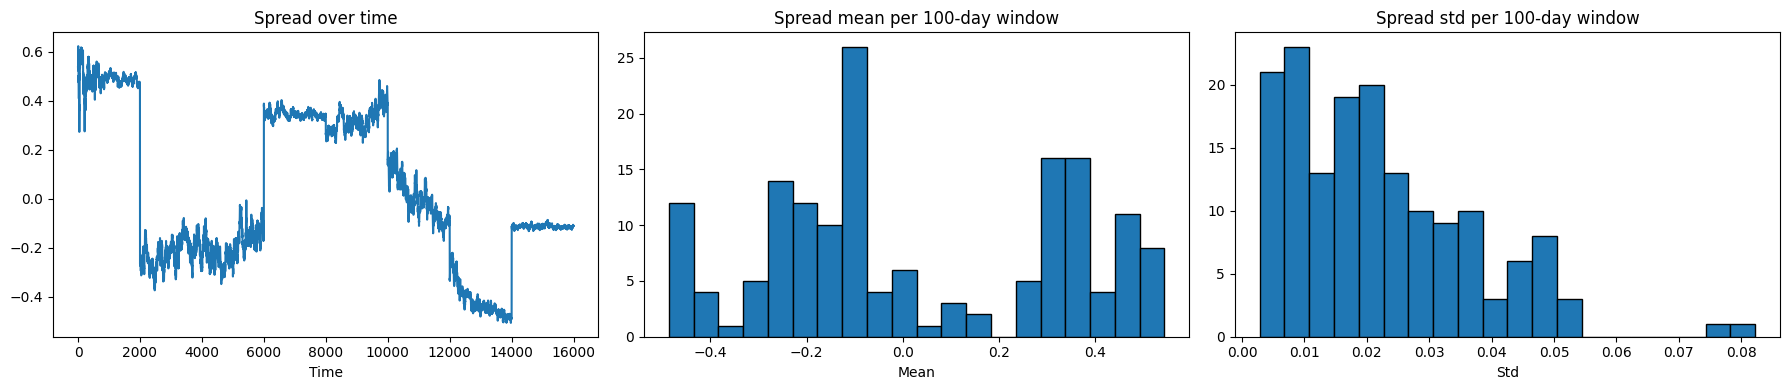

Mean:  range [-0.4863, 0.5440],  std of means = 0.3063
Std:   range [0.0028,  0.0822],  std of stds  = 0.0146


In [ ]:
def spread_stats_over_windows(s1, s2, window=100):
    log_s1, log_s2 = np.log(np.array(s1, dtype=float)), np.log(np.array(s2, dtype=float))
    beta = LinearRegression(fit_intercept=False).fit(log_s2.reshape(-1, 1), log_s1).coef_[0]
    spread = log_s1 - beta * log_s2

    means, stds = [], []
    for i in range(0, len(spread) - window, window):
        w = spread[i:i + window]
        means.append(w.mean())
        stds.append(w.std())
    return spread, np.array(means), np.array(stds)

spread, means, stds = spread_stats_over_windows(s1_gen, s2_gen, window=100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(spread)
axes[0].set_title("Spread over time")
axes[0].set_xlabel("Time")
axes[1].hist(means, bins=20, edgecolor='k')
axes[1].set_title("Spread mean per 100-day window")
axes[1].set_xlabel("Mean")
axes[2].hist(stds, bins=20, edgecolor='k')
axes[2].set_title("Spread std per 100-day window")
axes[2].set_xlabel("Std")
plt.tight_layout()
plt.show()

print(f"Mean:  range [{means.min():.4f}, {means.max():.4f}],  std of means = {means.std():.4f}")
print(f"Std:   range [{stds.min():.4f},  {stds.max():.4f}],  std of stds  = {stds.std():.4f}")

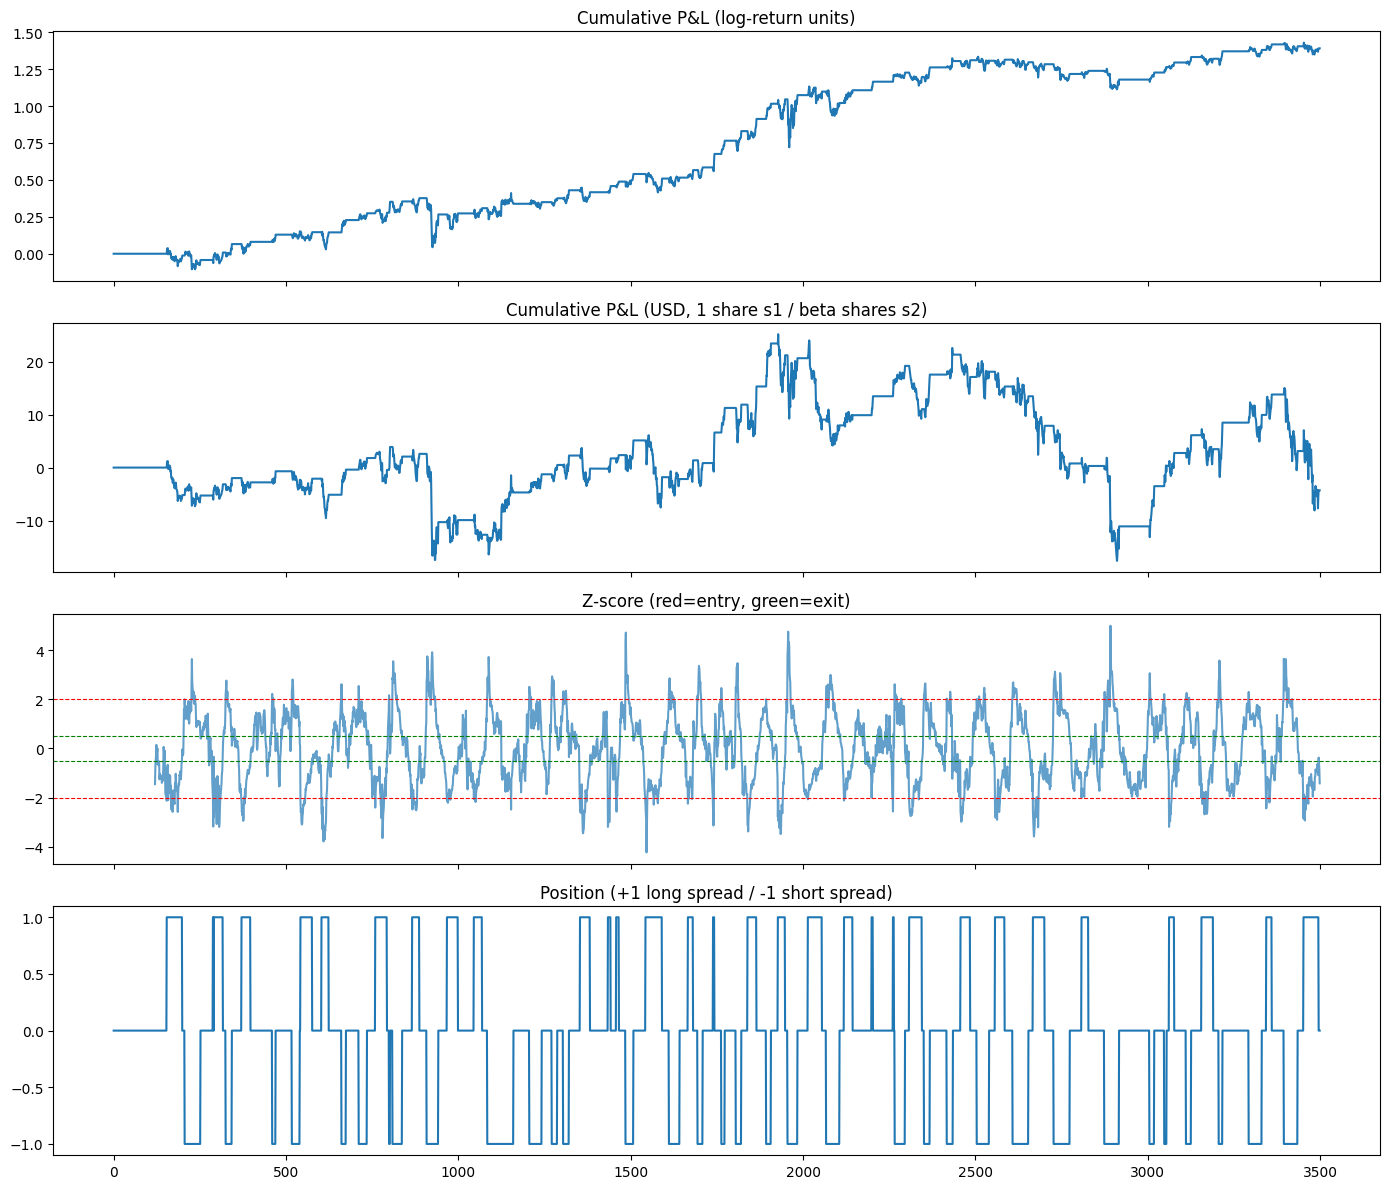

Sharpe:       0.547
Total ret:    1.3911
Max drawdown: 0.3322
Total USD P&L: $-4.30


In [ ]:
results = static_threshold_baseline(data_apple.values, data_microsoft.values)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(results["cum_ret"])
axes[0].set_title("Cumulative P&L (log-return units)")
axes[1].plot(results["cum_dollar_pnl"])
axes[1].set_title("Cumulative P&L (USD, 1 share s1 / beta shares s2)")
axes[2].plot(results["z"], alpha=0.7)
axes[2].axhline(2.0,  color='r', linestyle='--', linewidth=0.8)
axes[2].axhline(-2.0, color='r', linestyle='--', linewidth=0.8)
axes[2].axhline(0.5,  color='g', linestyle='--', linewidth=0.8)
axes[2].axhline(-0.5, color='g', linestyle='--', linewidth=0.8)
axes[2].set_title("Z-score (red=entry, green=exit)")
axes[3].plot(results["position"])
axes[3].set_title("Position (+1 long spread / -1 short spread)")
plt.tight_layout()
plt.show()

print(f"Sharpe:       {results['sharpe']:.3f}")
print(f"Total ret:    {results['total_ret']:.4f}")
print(f"Max drawdown: {results['max_dd']:.4f}")
print(f"Total USD P&L: ${results['cum_dollar_pnl'][-1]:.2f}")

In [ ]:
import pandas as pd

pair = pd.DataFrame({
    "PSX": data_apple,
    "MPC": data_microsoft,
})
pair.index = pair.index.map(lambda t: int(t.timestamp()))
pair.index.name = "timestamp"
pair.to_csv("data/real_pair_PSX_MPC.csv")


In [25]:
import yfinance as yf
import pandas as pd
import os

pairs = [
    ("MPC",  "PSX"),   # Marathon Petroleum vs Phillips 66
    ("PEP",  "KO"),    # Pepsi vs Coca-Cola
    ("AAPL", "MSFT"),  # Apple vs Microsoft
    ("JPM",  "BAC"),   # JPMorgan vs Bank of America
    ("XOM",  "CVX"),   # ExxonMobil vs Chevron
    ("MCD",  "YUM"),   # McDonald's vs Yum! Brands
    ("GS",   "MS"),    # Goldman Sachs vs Morgan Stanley
    ("V",    "MA"),    # Visa vs Mastercard
    ("HD",   "LOW"),   # Home Depot vs Lowe's
    ("T",    "VZ"),    # AT&T vs Verizon
]

os.makedirs("data", exist_ok=True)

for t1, t2 in pairs:
    df1 = yf.Ticker(t1).history(period="20y")["Close"]
    df2 = yf.Ticker(t2).history(period="20y")["Close"]
    df = pd.DataFrame({t1: df1, t2: df2}).dropna()
    df.index = df.index.map(lambda t: int(t.timestamp()))
    df.index.name = "timestamp"
    path = f"data/real_pair_{t1}_{t2}.csv"
    df.to_csv(path)
    print(f"Saved {path}  ({len(df)} rows)")


Saved data/real_pair_MPC_PSX.csv  (3544 rows)
Saved data/real_pair_PEP_KO.csv  (5032 rows)
Saved data/real_pair_AAPL_MSFT.csv  (5032 rows)
Saved data/real_pair_JPM_BAC.csv  (5032 rows)
Saved data/real_pair_XOM_CVX.csv  (5032 rows)
Saved data/real_pair_MCD_YUM.csv  (5032 rows)
Saved data/real_pair_GS_MS.csv  (5032 rows)
Saved data/real_pair_V_MA.csv  (4569 rows)
Saved data/real_pair_HD_LOW.csv  (5032 rows)
Saved data/real_pair_T_VZ.csv  (5032 rows)
